# Firing Rate Map: Step-by-Step for One Neuron

This notebook visualizes every intermediate step used to turn one neuron's activation trace plus a trajectory file into a spatial firing-rate map.

Edit `ACTIVATION_PATH`, `TRAJECTORY_PATH`, `LAYER_NAME`, and `NEURON_NUMBER` in the first code cell to inspect a different neuron.

In [5]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import signal

PROJECT_ROOT = Path('/Users/sindhuramrutha/documents/project_ventures/cns_lab/hpc_liza/2d_hippocampal_cells/2D-place-cell-generation-code/manoj_core')
ROUGHWORK_ROOT = PROJECT_ROOT / 'roughwork'
EXPERIMENT_ROOT = PROJECT_ROOT / 'experimental_observations' / 'blurred_blackwalls_analysis'
METADATA_PATH = EXPERIMENT_ROOT / 'simulation_metadata.json'

# Defaults use the coloured-wall activations from the recent coloured/blurred/black experiment.
ACTIVATION_PATH = PROJECT_ROOT / 'activations_colouredwalls.pkl'
TRAJECTORY_PATH = PROJECT_ROOT / 'traj_square_2objs_colouredwalls.pkl'

if TRAJECTORY_PATH is None and METADATA_PATH.exists():
    with open(METADATA_PATH, 'r') as f:
        TRAJECTORY_PATH = Path(json.load(f)['trajectory_path'])

# Choose the neuron to inspect. NEURON_NUMBER is 1-based, matching plot labels.
LAYER_NAME = 'MEC'
NEURON_NUMBER = 1

# Same defaults used in the firing-map visualization code.
THRESH_PARAM = 1.5
RES_PARAM = 80
GAUSSIAN_SHAPE = (9, 9)
GAUSSIAN_SIGMA = 3.0

SAVE_FIGURES = True
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Activation file:', ACTIVATION_PATH)
print('Trajectory file:', TRAJECTORY_PATH)
print('Layer:', LAYER_NAME, '| Neuron number:', NEURON_NUMBER)
print('Output dir:', OUTPUT_DIR)

Activation file: /Users/sindhuramrutha/documents/project_ventures/cns_lab/hpc_liza/2d_hippocampal_cells/2D-place-cell-generation-code/manoj_core/activations_colouredwalls.pkl
Trajectory file: /Users/sindhuramrutha/documents/project_ventures/cns_lab/hpc_liza/2d_hippocampal_cells/2D-place-cell-generation-code/manoj_core/traj_square_2objs_colouredwalls.pkl
Layer: MEC | Neuron number: 1
Output dir: /Users/sindhuramrutha/documents/project_ventures/cns_lab/hpc_liza/2d_hippocampal_cells/2D-place-cell-generation-code/manoj_core/outputs


## Helper Functions

In [6]:
def load_pickle(path: Path):
    with open(Path(path).expanduser(), 'rb') as f:
        return pickle.load(f)


def matlab_style_gauss2D(shape=(3, 3), sigma=0.5):
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y) / (2. * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h


def load_trajectory(path: Path) -> dict:
    raw = load_pickle(path)
    if not isinstance(raw, dict) or 'x' not in raw or 'y' not in raw:
        raise ValueError('Trajectory pickle must be a dict with x and y arrays')

    x = np.asarray(raw['x'])
    y = np.asarray(raw['y'])
    traj = {
        'x': x,
        'y': y,
        'theta': np.asarray(raw.get('theta', np.zeros(len(x)))),
        'pos': np.column_stack((x, y)),
    }
    for key in ['objects', 'obj', 'obj_params', 'config']:
        if key in raw:
            traj[key] = raw[key]
    return traj


def normalize_layer_shape(layer_activations: np.ndarray, trajectory_len: int) -> np.ndarray:
    arr = np.asarray(layer_activations)
    if arr.ndim != 2:
        raise ValueError(f'Layer activation must be 2D, got shape {arr.shape}')
    if arr.shape[0] != trajectory_len and arr.shape[1] == trajectory_len:
        arr = arr.T
    return arr


def extract_objects_info(trajectory_data: dict) -> list:
    objects_info = []
    if 'objects' in trajectory_data and trajectory_data['objects']:
        for obj in trajectory_data['objects']:
            if isinstance(obj, dict) and 'center' in obj and 'size' in obj:
                center_x, center_y = obj['center']
                width, height = obj['size']
                objects_info.append({'center': (float(center_x), float(center_y)), 'width': float(width), 'height': float(height)})
    elif 'obj' in trajectory_data and trajectory_data['obj'] is not None:
        obj_array = np.asarray(trajectory_data['obj'])
        if len(obj_array.shape) == 3 and obj_array.shape[0] > 0:
            for vertices in obj_array:
                vertices = np.asarray(vertices)
                if len(vertices) > 1 and np.allclose(vertices[0], vertices[-1]):
                    vertices = vertices[:-1]
                objects_info.append({
                    'center': (float(vertices[:, 0].mean()), float(vertices[:, 1].mean())),
                    'width': float(vertices[:, 0].max() - vertices[:, 0].min()),
                    'height': float(vertices[:, 1].max() - vertices[:, 1].min()),
                })
    elif 'obj_params' in trajectory_data:
        centers = trajectory_data['obj_params'].get('obj_center', [])
        half_x = float(trajectory_data['obj_params'].get('hf_sz_x', 0.05))
        half_y = float(trajectory_data['obj_params'].get('hf_sz_y', 0.05))
        for center_x, center_y in centers:
            objects_info.append({'center': (float(center_x), float(center_y)), 'width': 2 * half_x, 'height': 2 * half_y})
    return objects_info


def add_object_patches(ax, objects_info, edgecolor='white', facecolor='white', alpha=1.0):
    for obj in objects_info:
        center_x, center_y = obj['center']
        width, height = obj['width'], obj['height']
        rect = patches.Rectangle(
            (center_x - width / 2, center_y - height / 2),
            width,
            height,
            linewidth=1.2,
            edgecolor=edgecolor,
            facecolor=facecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)


def savefig(fig, name: str):
    if SAVE_FIGURES:
        path = OUTPUT_DIR / name
        fig.savefig(path, dpi=160, bbox_inches='tight')
        print('saved:', path.name)

## Load Data and Build Every Intermediate Array

In [7]:
activations = load_pickle(ACTIVATION_PATH)
trajectory = load_trajectory(TRAJECTORY_PATH)

if LAYER_NAME not in activations:
    raise KeyError(f'{LAYER_NAME!r} not found. Available layers: {list(activations.keys())}')

layer_activations = normalize_layer_shape(activations[LAYER_NAME], len(trajectory['x']))
n_samples = min(layer_activations.shape[0], len(trajectory['x']))
layer_activations = layer_activations[:n_samples]
x = trajectory['x'][:n_samples]
y = trajectory['y'][:n_samples]
pos = np.column_stack((x, y))

neuron_idx = int(NEURON_NUMBER) - 1
if neuron_idx < 0 or neuron_idx >= layer_activations.shape[1]:
    raise IndexError(f'NEURON_NUMBER must be between 1 and {layer_activations.shape[1]} for layer {LAYER_NAME}')

neuron_activity = layer_activations[:, neuron_idx]

mean_resp = float(np.mean(neuron_activity))
std_resp = float(np.std(neuron_activity))
threshold = mean_resp + THRESH_PARAM * std_resp
firing_indices = np.where(neuron_activity > threshold)[0]
firing_positions = pos[firing_indices]
firing_values = neuron_activity[firing_indices]

xmin, xmax = float(pos[:, 0].min()), float(pos[:, 0].max())
ymin, ymax = float(pos[:, 1].min()), float(pos[:, 1].max())
extent = [xmin, xmax, ymin, ymax]
x_bins = np.linspace(xmin, xmax, RES_PARAM)
y_bins = np.linspace(ymin, ymax, RES_PARAM)

raw_firing_map = np.zeros((RES_PARAM, RES_PARAM), dtype=float)
assigned_bins = []
for value, (fx, fy) in zip(firing_values, firing_positions):
    x_idx = int(np.argmin(np.abs(x_bins - fx)))
    y_idx = int(np.argmin(np.abs(y_bins - fy)))
    old_value = raw_firing_map[y_idx, x_idx]
    raw_firing_map[y_idx, x_idx] = max(old_value, value)
    assigned_bins.append((x_idx, y_idx, float(value), float(old_value), float(raw_firing_map[y_idx, x_idx])))

if raw_firing_map.max() > 0:
    normalized_firing_map = raw_firing_map / raw_firing_map.max()
else:
    normalized_firing_map = raw_firing_map.copy()

gaussian_kernel = matlab_style_gauss2D(GAUSSIAN_SHAPE, GAUSSIAN_SIGMA)
smoothed_firing_map = signal.convolve2d(normalized_firing_map, gaussian_kernel, mode='same')

# Occupancy is shown for intuition. The visualization path above does not divide by occupancy.
occupancy_counts, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=RES_PARAM)
occupancy_counts = occupancy_counts.T

objects_info = extract_objects_info(trajectory)

print(f'Layer activations shape after alignment: {layer_activations.shape}')
print(f'Position samples after alignment: {pos.shape}')
print(f'Neuron activity shape: {neuron_activity.shape}')
print(f'Mean={mean_resp:.6f}, std={std_resp:.6f}, threshold={threshold:.6f}')
print(f'Firing samples above threshold: {len(firing_indices)} / {n_samples} ({len(firing_indices) / n_samples * 100:.3f}%)')
print(f'Raw map nonzero bins: {np.count_nonzero(raw_firing_map)}')
print(f'Map resolution: {RES_PARAM} x {RES_PARAM}')
print(f'Objects found: {len(objects_info)}')

Layer activations shape after alignment: (30001, 32)
Position samples after alignment: (30001, 2)
Neuron activity shape: (30001,)
Mean=0.597370, std=1.001078, threshold=2.098987
Firing samples above threshold: 2911 / 30001 (9.703%)
Raw map nonzero bins: 321
Map resolution: 80 x 80
Objects found: 2


## Step 1: Activation Trace and Threshold

The activation file gives one value per timestep for this neuron. The firing threshold is `mean + 1.5 * std`.

saved: 01_activation_trace_and_threshold.png


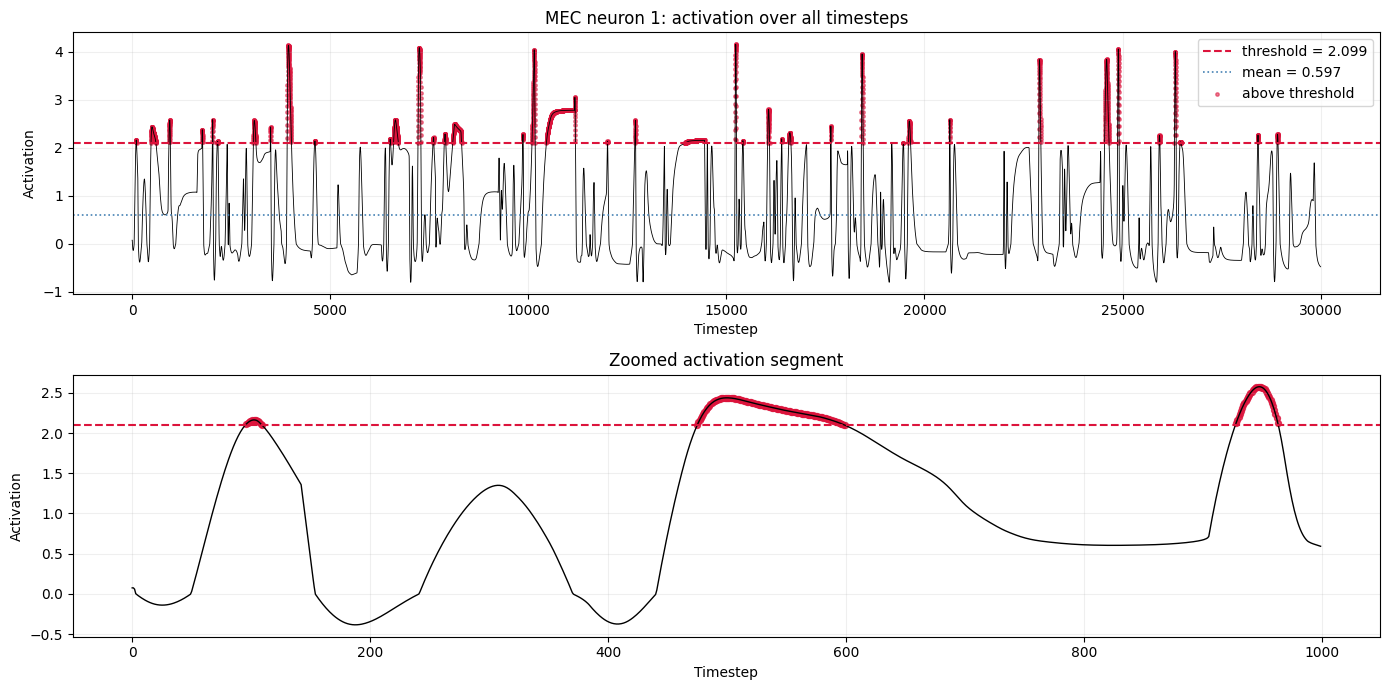

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(neuron_activity, linewidth=0.6, color='black')
axes[0].axhline(threshold, color='crimson', linestyle='--', linewidth=1.5, label=f'threshold = {threshold:.3f}')
axes[0].axhline(mean_resp, color='steelblue', linestyle=':', linewidth=1.2, label=f'mean = {mean_resp:.3f}')
axes[0].scatter(firing_indices, neuron_activity[firing_indices], s=6, color='crimson', alpha=0.55, label='above threshold')
axes[0].set_title(f'{LAYER_NAME} neuron {NEURON_NUMBER}: activation over all timesteps')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Activation')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.2)

zoom_start = int(firing_indices[0]) - 250 if len(firing_indices) else 0
zoom_start = max(0, zoom_start)
zoom_end = min(n_samples, zoom_start + 1000)
zoom_range = np.arange(zoom_start, zoom_end)
axes[1].plot(zoom_range, neuron_activity[zoom_start:zoom_end], linewidth=1.0, color='black')
axes[1].axhline(threshold, color='crimson', linestyle='--', linewidth=1.5)
zoom_fires = firing_indices[(firing_indices >= zoom_start) & (firing_indices < zoom_end)]
axes[1].scatter(zoom_fires, neuron_activity[zoom_fires], s=18, color='crimson', alpha=0.8)
axes[1].set_title('Zoomed activation segment')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Activation')
axes[1].grid(alpha=0.2)

plt.tight_layout()
savefig(fig, '01_activation_trace_and_threshold.png')
plt.show()

## Step 2: Which Activation Values Count as Firing?

This histogram shows the distribution of activation values. Only values to the right of the red threshold line are retained as firing events.

saved: 02_activation_histogram_threshold.png


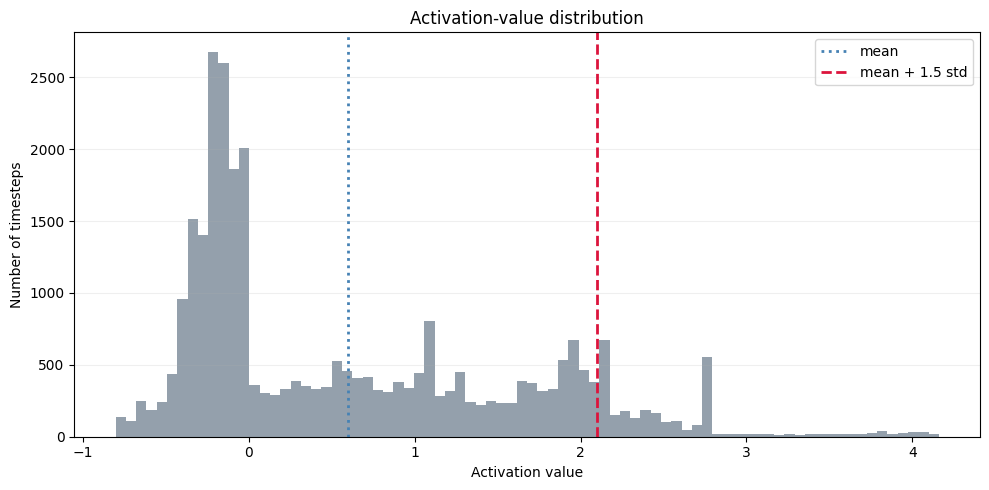

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(neuron_activity, bins=80, color='slategray', alpha=0.75)
ax.axvline(mean_resp, color='steelblue', linestyle=':', linewidth=2, label='mean')
ax.axvline(threshold, color='crimson', linestyle='--', linewidth=2, label='mean + 1.5 std')
ax.set_title('Activation-value distribution')
ax.set_xlabel('Activation value')
ax.set_ylabel('Number of timesteps')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
savefig(fig, '02_activation_histogram_threshold.png')
plt.show()

## Step 3: Convert Firing Times into Firing Positions

Each firing timestep is mapped to the animal's `(x, y)` position at that same timestep.

saved: 03_trajectory_to_firing_positions.png


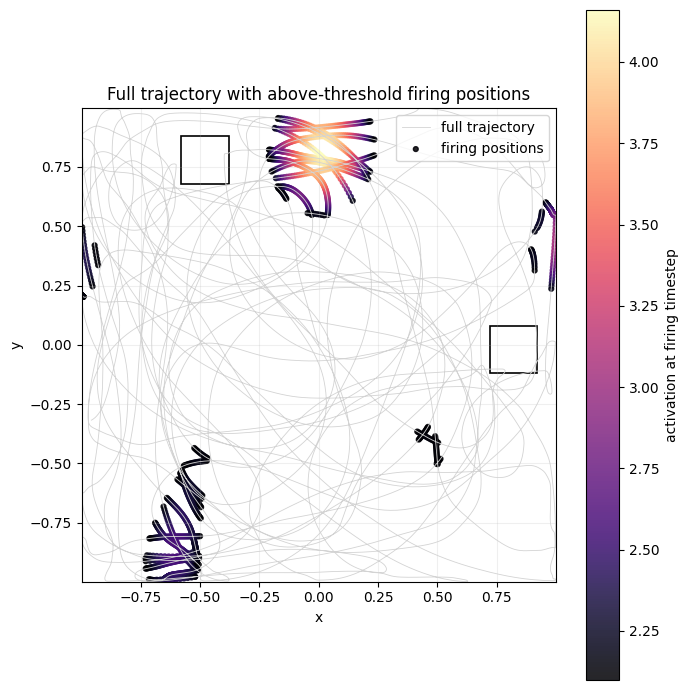

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(pos[:, 0], pos[:, 1], color='lightgray', linewidth=0.6, label='full trajectory')
if len(firing_positions):
    sc = ax.scatter(
        firing_positions[:, 0],
        firing_positions[:, 1],
        c=firing_values,
        cmap='magma',
        s=12,
        alpha=0.85,
        label='firing positions',
    )
    fig.colorbar(sc, ax=ax, label='activation at firing timestep')
add_object_patches(ax, objects_info, edgecolor='black', facecolor='white')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')
ax.set_title('Full trajectory with above-threshold firing positions')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
savefig(fig, '03_trajectory_to_firing_positions.png')
plt.show()

## Step 4: Define the 80 x 80 Spatial Grid

The arena bounds are split into `RES_PARAM` bins along x and y. The occupancy plot is shown for intuition; this visualization code does not divide the firing map by occupancy.

saved: 04_spatial_grid_and_occupancy.png


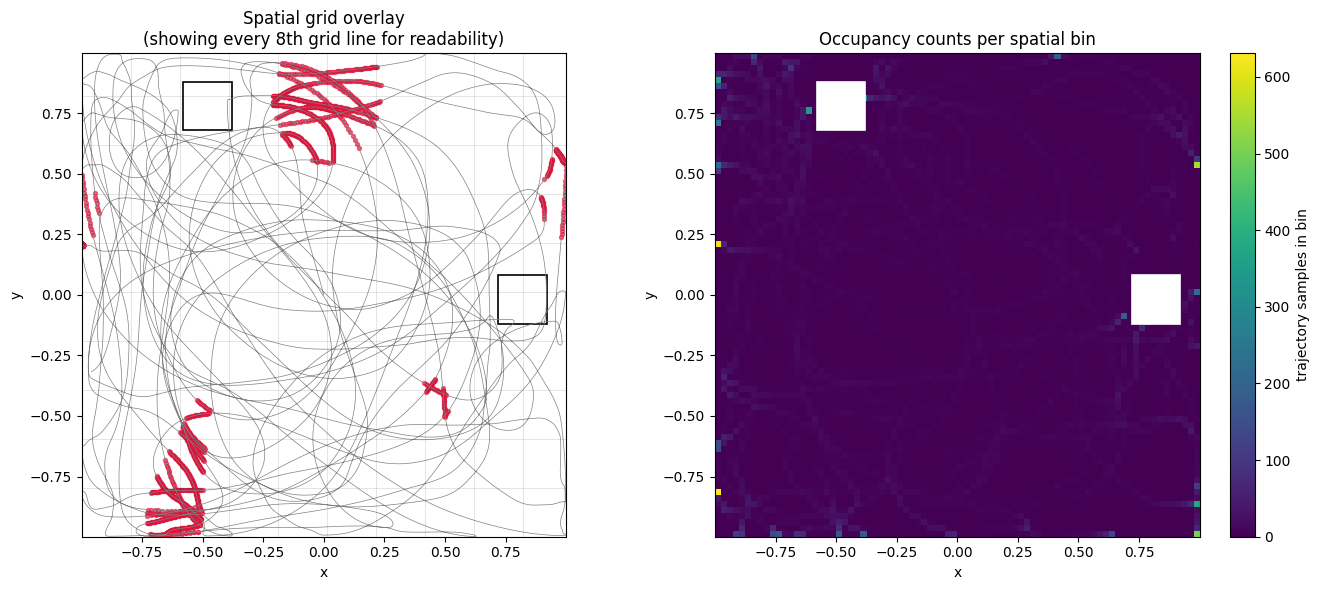

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(pos[:, 0], pos[:, 1], color='gray', linewidth=0.5)
if len(firing_positions):
    axes[0].scatter(firing_positions[:, 0], firing_positions[:, 1], color='crimson', s=8, alpha=0.6)
for xb in x_bins[::8]:
    axes[0].axvline(xb, color='black', alpha=0.12, linewidth=0.6)
for yb in y_bins[::8]:
    axes[0].axhline(yb, color='black', alpha=0.12, linewidth=0.6)
add_object_patches(axes[0], objects_info, edgecolor='black', facecolor='white')
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)
axes[0].set_aspect('equal')
axes[0].set_title('Spatial grid overlay\n(showing every 8th grid line for readability)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im = axes[1].imshow(occupancy_counts, origin='lower', extent=extent, cmap='viridis', aspect='equal')
add_object_patches(axes[1], objects_info, edgecolor='white', facecolor='white')
axes[1].set_title('Occupancy counts per spatial bin')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im, ax=axes[1], label='trajectory samples in bin')

plt.tight_layout()
savefig(fig, '04_spatial_grid_and_occupancy.png')
plt.show()

## Step 5: Bin Firing Values into the Spatial Grid

For every firing position, the nearest x-bin and y-bin are found. If multiple firing events land in the same bin, the maximum activation value is kept.

saved: 05_binned_raw_firing_map.png


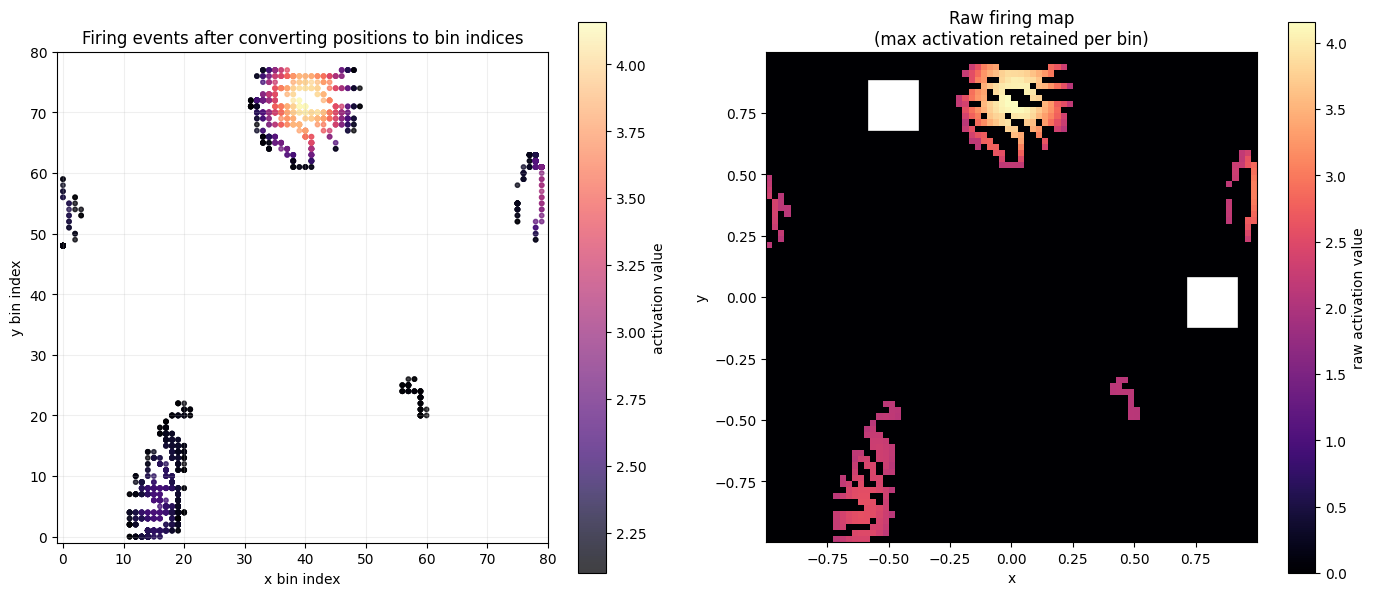

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if assigned_bins:
    assigned = np.array(assigned_bins)
    sc = axes[0].scatter(assigned[:, 0], assigned[:, 1], c=assigned[:, 2], cmap='magma', s=10, alpha=0.75)
    fig.colorbar(sc, ax=axes[0], label='activation value')
axes[0].set_xlim(-1, RES_PARAM)
axes[0].set_ylim(-1, RES_PARAM)
axes[0].set_aspect('equal')
axes[0].set_title('Firing events after converting positions to bin indices')
axes[0].set_xlabel('x bin index')
axes[0].set_ylabel('y bin index')
axes[0].grid(alpha=0.2)

im = axes[1].imshow(raw_firing_map, cmap='magma', origin='lower', extent=extent, aspect='equal')
add_object_patches(axes[1], objects_info, edgecolor='white', facecolor='white')
axes[1].set_title('Raw firing map\n(max activation retained per bin)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im, ax=axes[1], label='raw activation value')

plt.tight_layout()
savefig(fig, '05_binned_raw_firing_map.png')
plt.show()

## Step 6: Normalize the Raw Firing Map

The raw map is divided by its maximum value, so the strongest bin becomes 1.0 and all other bins are relative to it.

saved: 06_normalized_firing_map.png


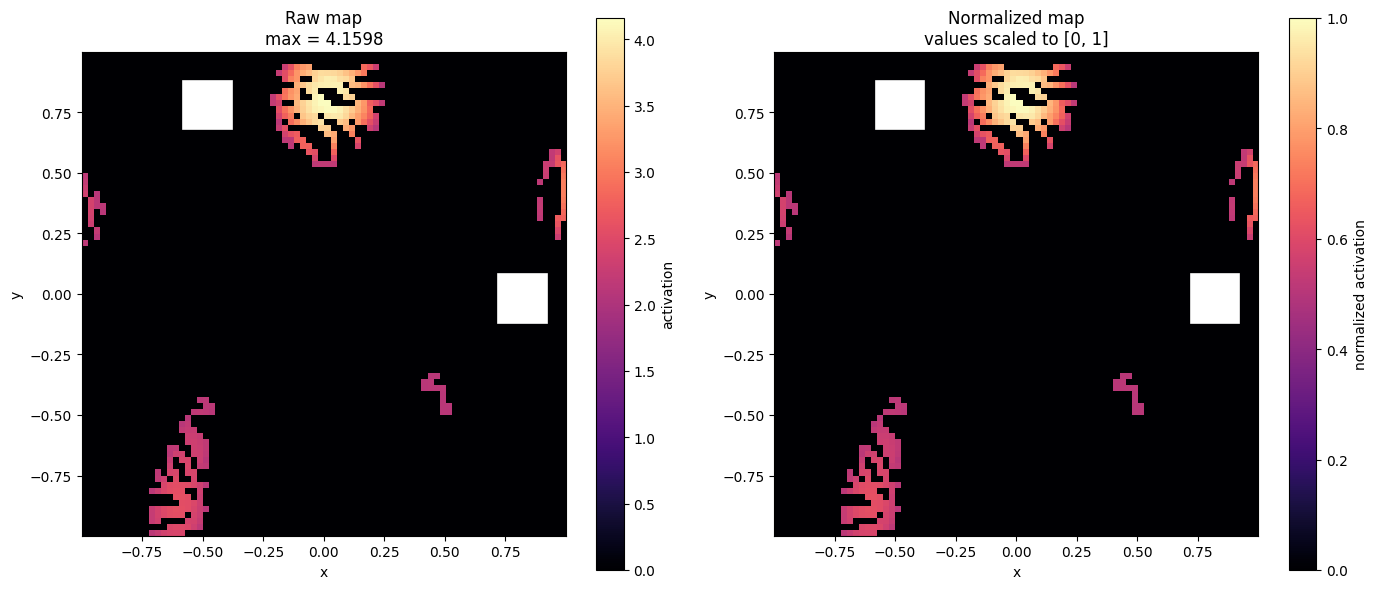

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(raw_firing_map, cmap='magma', origin='lower', extent=extent, aspect='equal')
add_object_patches(axes[0], objects_info, edgecolor='white', facecolor='white')
axes[0].set_title(f'Raw map\nmax = {raw_firing_map.max():.4f}')
fig.colorbar(im0, ax=axes[0], label='activation')

im1 = axes[1].imshow(normalized_firing_map, cmap='magma', origin='lower', extent=extent, aspect='equal', vmin=0, vmax=1)
add_object_patches(axes[1], objects_info, edgecolor='white', facecolor='white')
axes[1].set_title('Normalized map\nvalues scaled to [0, 1]')
fig.colorbar(im1, ax=axes[1], label='normalized activation')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
savefig(fig, '06_normalized_firing_map.png')
plt.show()

## Step 7: Build the Gaussian Smoothing Kernel

The normalized map is smoothed with a 9 x 9 Gaussian kernel with sigma 3.0. This turns isolated bin hits into smoother spatial fields.

saved: 07_gaussian_kernel.png


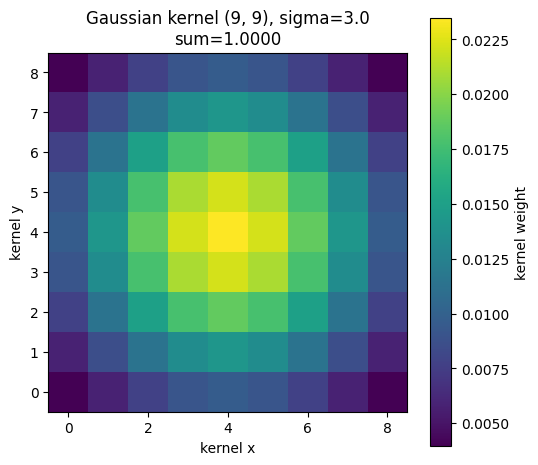

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(gaussian_kernel, cmap='viridis', origin='lower')
ax.set_title(f'Gaussian kernel {GAUSSIAN_SHAPE}, sigma={GAUSSIAN_SIGMA}\nsum={gaussian_kernel.sum():.4f}')
ax.set_xlabel('kernel x')
ax.set_ylabel('kernel y')
fig.colorbar(im, ax=ax, label='kernel weight')
plt.tight_layout()
savefig(fig, '07_gaussian_kernel.png')
plt.show()

## Step 8: Smooth the Normalized Map

The final plotted firing-rate map is the normalized map convolved with the Gaussian kernel.

saved: 08_smoothed_final_firing_map.png


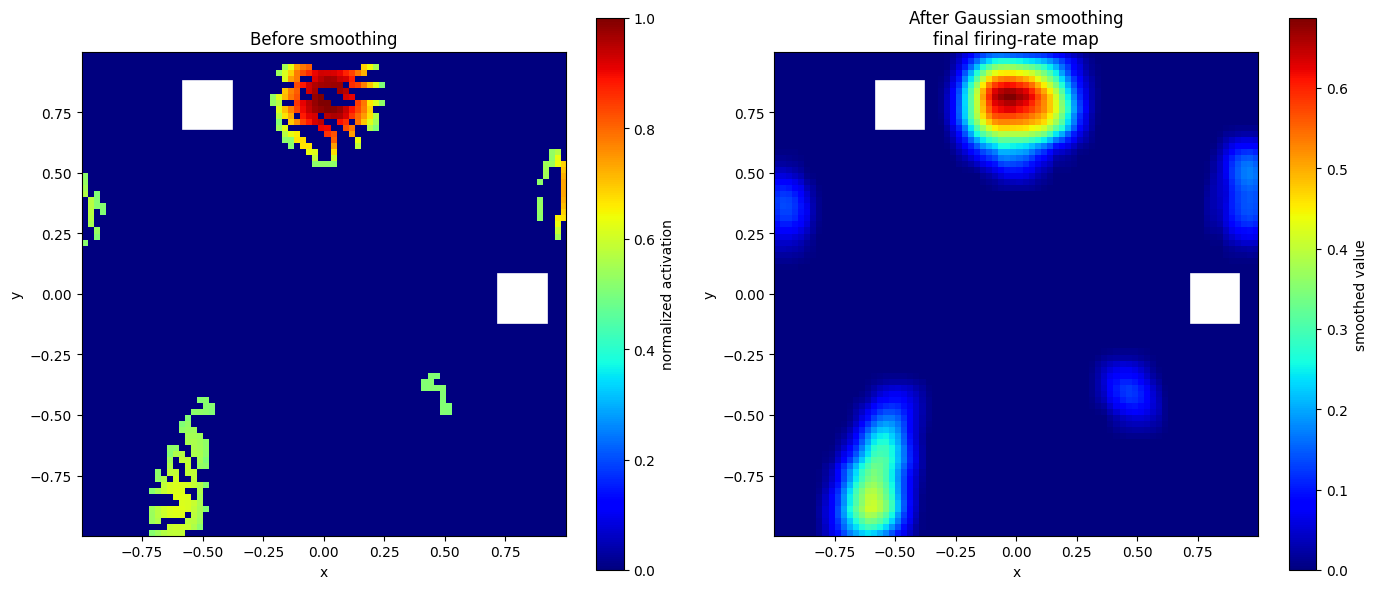

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(normalized_firing_map, cmap='jet', origin='lower', extent=extent, aspect='equal', vmin=0, vmax=1)
add_object_patches(axes[0], objects_info, edgecolor='white', facecolor='white')
axes[0].set_title('Before smoothing')
fig.colorbar(im0, ax=axes[0], label='normalized activation')

im1 = axes[1].imshow(smoothed_firing_map, cmap='jet', origin='lower', extent=extent, aspect='equal')
add_object_patches(axes[1], objects_info, edgecolor='white', facecolor='white')
axes[1].set_title('After Gaussian smoothing\nfinal firing-rate map')
fig.colorbar(im1, ax=axes[1], label='smoothed value')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
savefig(fig, '08_smoothed_final_firing_map.png')
plt.show()

## Step 9: One-Page Summary of the Whole Pipeline

saved: 09_pipeline_summary.png


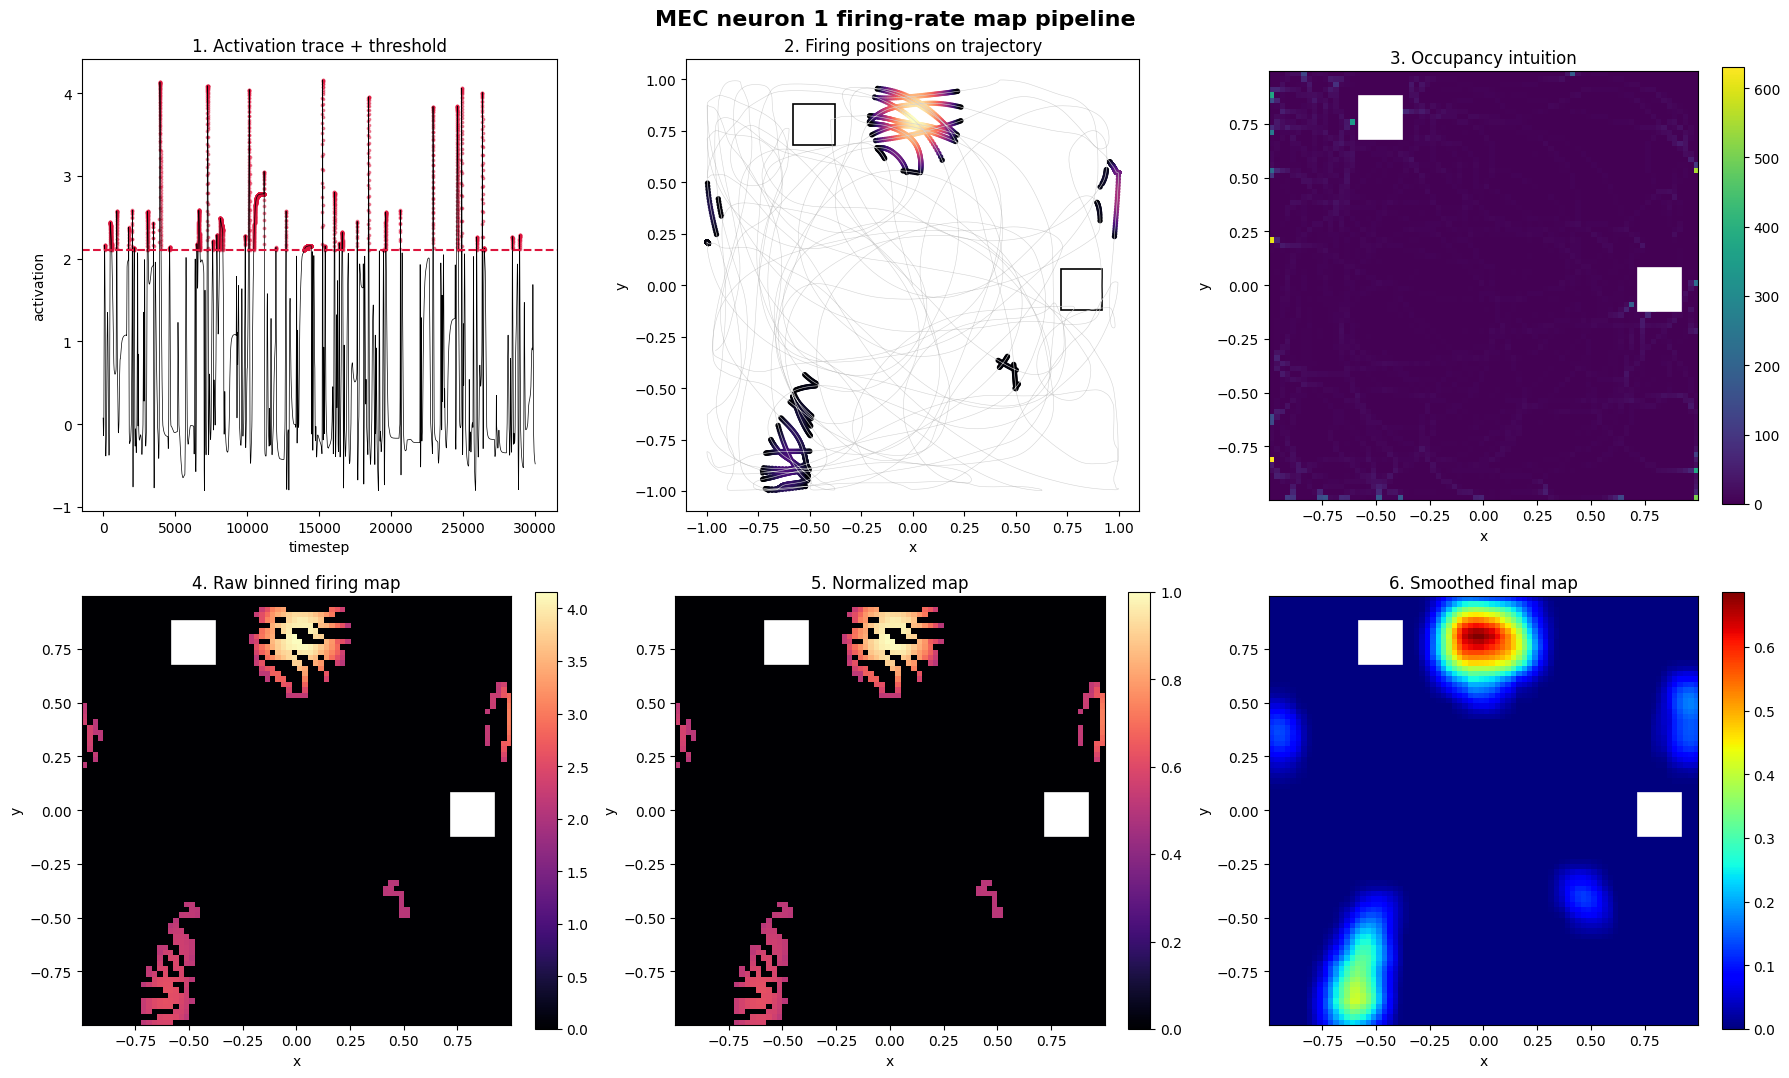

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

axes[0].plot(neuron_activity, linewidth=0.5, color='black')
axes[0].axhline(threshold, color='crimson', linestyle='--')
axes[0].scatter(firing_indices, neuron_activity[firing_indices], s=3, color='crimson', alpha=0.45)
axes[0].set_title('1. Activation trace + threshold')
axes[0].set_xlabel('timestep')
axes[0].set_ylabel('activation')

axes[1].plot(pos[:, 0], pos[:, 1], color='lightgray', linewidth=0.4)
if len(firing_positions):
    axes[1].scatter(firing_positions[:, 0], firing_positions[:, 1], c=firing_values, cmap='magma', s=8)
add_object_patches(axes[1], objects_info, edgecolor='black', facecolor='white')
axes[1].set_title('2. Firing positions on trajectory')
axes[1].set_aspect('equal')

im2 = axes[2].imshow(occupancy_counts, origin='lower', extent=extent, cmap='viridis', aspect='equal')
add_object_patches(axes[2], objects_info, edgecolor='white', facecolor='white')
axes[2].set_title('3. Occupancy intuition')
fig.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(raw_firing_map, origin='lower', extent=extent, cmap='magma', aspect='equal')
add_object_patches(axes[3], objects_info, edgecolor='white', facecolor='white')
axes[3].set_title('4. Raw binned firing map')
fig.colorbar(im3, ax=axes[3], fraction=0.046)

im4 = axes[4].imshow(normalized_firing_map, origin='lower', extent=extent, cmap='magma', aspect='equal', vmin=0, vmax=1)
add_object_patches(axes[4], objects_info, edgecolor='white', facecolor='white')
axes[4].set_title('5. Normalized map')
fig.colorbar(im4, ax=axes[4], fraction=0.046)

im5 = axes[5].imshow(smoothed_firing_map, origin='lower', extent=extent, cmap='jet', aspect='equal')
add_object_patches(axes[5], objects_info, edgecolor='white', facecolor='white')
axes[5].set_title('6. Smoothed final map')
fig.colorbar(im5, ax=axes[5], fraction=0.046)

for ax in axes[1:]:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.suptitle(f'{LAYER_NAME} neuron {NEURON_NUMBER} firing-rate map pipeline', fontsize=16, fontweight='bold')
plt.tight_layout()
savefig(fig, '09_pipeline_summary.png')
plt.show()

## Notes

- The visualization path shown here matches the firing-map plotting style used in the app/notebooks: threshold high activations, place them into an 80 x 80 spatial grid, normalize, smooth, and plot.
- The occupancy map is shown for intuition, but this particular visualization does not divide the displayed map by occupancy.
- Some detector internals, especially place/grid/border scoring, do use occupancy normalization when calculating spatial-cell metrics.

## Final Comparison: Three Firing-Map Definitions

This section uses the same activation trace, trajectory, threshold, grid resolution, and Gaussian smoother as above. It compares three common map-building choices for the same neuron:

1. `sum activation in bin / occupancy`
2. `max activation in bin / global max activation-bin value`
3. `max activation in bin / occupancy`

The occupancy denominator below is the smoothed occupancy-count map, which is the most interpretable form of dwell-time correction. Dividing by normalized occupancy probability would preserve the same spatial pattern but multiply the values by a constant.

In [17]:
def safe_peak_normalize(map_array: np.ndarray) -> np.ndarray:
    arr = np.asarray(map_array, dtype=float)
    max_val = np.nanmax(arr) if arr.size else 0.0
    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(arr)
    return arr / max_val


def build_three_firing_map_versions(
    activity: np.ndarray,
    pos: np.ndarray,
    threshold: float,
    res_param: int,
    gaussian_kernel: np.ndarray,
) -> dict:
    """Build three firing-map variants for the same neuron and trajectory."""
    xmin, xmax = float(pos[:, 0].min()), float(pos[:, 0].max())
    ymin, ymax = float(pos[:, 1].min()), float(pos[:, 1].max())
    x_grid = np.linspace(xmin, xmax, res_param)
    y_grid = np.linspace(ymin, ymax, res_param)

    firing_idx = np.flatnonzero(activity > threshold)
    sum_activation_map = np.zeros((res_param, res_param), dtype=float)
    max_activation_map = np.zeros((res_param, res_param), dtype=float)
    firing_event_count_map = np.zeros((res_param, res_param), dtype=float)

    for idx in firing_idx:
        col = int(np.argmin(np.abs(pos[idx, 0] - x_grid)))
        row = int(np.argmin(np.abs(pos[idx, 1] - y_grid)))
        value = float(activity[idx])
        sum_activation_map[row, col] += value
        max_activation_map[row, col] = max(max_activation_map[row, col], value)
        firing_event_count_map[row, col] += 1

    occupancy_counts_local, _, _ = np.histogram2d(
        pos[:, 0],
        pos[:, 1],
        bins=res_param,
        range=[[xmin, xmax], [ymin, ymax]],
    )
    occupancy_counts_local = occupancy_counts_local.T
    occupancy_smooth = signal.convolve2d(occupancy_counts_local, gaussian_kernel, mode='same')

    occupancy_safe = occupancy_smooth.copy()
    occupancy_safe[occupancy_safe <= 1e-9] = np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        sum_over_occupancy = sum_activation_map / occupancy_safe
        max_over_occupancy = max_activation_map / occupancy_safe

    sum_over_occupancy = np.nan_to_num(sum_over_occupancy, nan=0.0, posinf=0.0, neginf=0.0)
    max_over_occupancy = np.nan_to_num(max_over_occupancy, nan=0.0, posinf=0.0, neginf=0.0)
    max_overall_max = safe_peak_normalize(max_activation_map)

    maps_raw = {
        'sum_over_occupancy': sum_over_occupancy,
        'max_overall_max': max_overall_max,
        'max_over_occupancy': max_over_occupancy,
    }
    maps_smoothed = {
        name: signal.convolve2d(map_array, gaussian_kernel, mode='same')
        for name, map_array in maps_raw.items()
    }

    return {
        'firing_indices': firing_idx,
        'sum_activation_map': sum_activation_map,
        'max_activation_map': max_activation_map,
        'firing_event_count_map': firing_event_count_map,
        'occupancy_counts': occupancy_counts_local,
        'occupancy_smooth': occupancy_smooth,
        'maps_raw': maps_raw,
        'maps_smoothed': maps_smoothed,
        'extent': [xmin, xmax, ymin, ymax],
    }


three_map_comparison = build_three_firing_map_versions(
    activity=neuron_activity,
    pos=pos,
    threshold=threshold,
    res_param=RES_PARAM,
    gaussian_kernel=gaussian_kernel,
)

print('Built three map versions for:')
print(f'  layer={LAYER_NAME}, neuron={NEURON_NUMBER}')
print(f'  firing events above threshold={len(three_map_comparison["firing_indices"])}')
print(f'  occupied bins={(three_map_comparison["occupancy_counts"] > 0).sum()} / {RES_PARAM * RES_PARAM}')

Built three map versions for:
  layer=MEC, neuron=1
  firing events above threshold=2911
  occupied bins=3657 / 6400


In [ ]:
comparison_items = [
    ('Sum / occupancy', 'sum_over_occupancy', 'activation per occupancy sample'),
    ('Max / overall max', 'max_overall_max', 'relative activation [0, 1]'),
    ('Max / occupancy', 'max_over_occupancy', 'max activation per occupancy sample'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col, (title, key, colorbar_label) in enumerate(comparison_items):
    map_values = three_map_comparison['maps_smoothed'][key]

    im0 = axes[col].imshow(
        map_values,
        cmap='jet',
        origin='lower',
        extent=three_map_comparison['extent'],
        aspect='equal',
    )
    add_object_patches(axes[col], objects_info, edgecolor='white', facecolor='white')
    axes[col].set_title(f'{title}\nactual values after smoothing (not renormalized)')
    axes[col].set_xlabel('x')
    axes[col].set_ylabel('y')
    fig.colorbar(im0, ax=axes[col], fraction=0.046, label=colorbar_label)

fig.suptitle(
    f'Three firing-map definitions for {LAYER_NAME} neuron {NEURON_NUMBER}\n(each panel keeps its own true scale; not peak-normalized)',
    fontsize=15,
    fontweight='bold',
)
plt.tight_layout()
savefig(fig, '10_three_firing_map_definitions_comparison.png')
plt.show()

In [19]:
print('Numeric summary for the three smoothed map versions:')
print('-' * 92)
print(f'{"map":<22} {"min":>12} {"max":>12} {"mean":>12} {"nonzero bins":>14} {"peak bin(y,x)":>16}')
print('-' * 92)

for title, key, _ in comparison_items:
    map_values = three_map_comparison['maps_smoothed'][key]
    peak_bin = np.unravel_index(np.argmax(map_values), map_values.shape)
    nonzero_bins = int(np.count_nonzero(map_values > 0))
    print(
        f'{title:<22} '
        f'{np.nanmin(map_values):>12.5f} '
        f'{np.nanmax(map_values):>12.5f} '
        f'{np.nanmean(map_values):>12.5f} '
        f'{nonzero_bins:>14d} '
        f'{str(tuple(int(v) for v in peak_bin)):>16}'
    )

Numeric summary for the three smoothed map versions:
--------------------------------------------------------------------------------------------
map                             min          max         mean   nonzero bins    peak bin(y,x)
--------------------------------------------------------------------------------------------
Sum / occupancy             0.00000      4.49711      0.20453           1486         (72, 40)
Max / overall max           0.00000      0.68691      0.03159           1486         (72, 39)
Max / occupancy             0.00000      1.07712      0.04464           1486         (73, 42)
